# Annotation Analysis

Examine and analyze the annotated intent data from the probability range 0.35-0.65.

## Import Required Libraries

In [1]:
import json
import pandas as pd
from pathlib import Path

## Load the JSON File

In [2]:
# Load the annotated data
annotation_file = Path('../data/annotations/intent_annotation_0.35-0.65.json')

with open(annotation_file, 'r') as f:
    annotation_data = json.load(f)

print(f"File loaded: {annotation_file}")
print(f"Type of data: {type(annotation_data)}")

File loaded: ../data/annotations/intent_annotation_0.35-0.65.json
Type of data: <class 'list'>


## Examine File Structure

In [3]:
# Examine the structure
if isinstance(annotation_data, list):
    print(f"Data is a list with {len(annotation_data)} entries")
    if len(annotation_data) > 0:
        print(f"\nFirst entry keys: {annotation_data[0].keys()}")
        print(f"\nFirst entry structure:")
        for key, value in annotation_data[0].items():
            print(f"  {key}: {type(value).__name__}")
elif isinstance(annotation_data, dict):
    print(f"Data is a dictionary with {len(annotation_data)} keys:")
    print(f"Keys: {list(annotation_data.keys())}")
else:
    print(f"Unexpected data type: {type(annotation_data)}")

Data is a list with 1767 entries

First entry keys: dict_keys(['id', 'annotations', 'file_upload', 'drafts', 'predictions', 'data', 'meta', 'created_at', 'updated_at', 'inner_id', 'total_annotations', 'cancelled_annotations', 'total_predictions', 'comment_count', 'unresolved_comment_count', 'last_comment_updated_at', 'project', 'updated_by', 'comment_authors'])

First entry structure:
  id: int
  annotations: list
  file_upload: str
  drafts: list
  predictions: list
  data: dict
  meta: dict
  created_at: str
  updated_at: str
  inner_id: int
  total_annotations: int
  cancelled_annotations: int
  total_predictions: int
  comment_count: int
  unresolved_comment_count: int
  last_comment_updated_at: NoneType
  project: int
  updated_by: int
  comment_authors: list


## Count Total Entries

In [4]:
# Count total entries
if isinstance(annotation_data, list):
    total_entries = len(annotation_data)
    print(f"Total number of entries: {total_entries}")
elif isinstance(annotation_data, dict):
    total_entries = len(annotation_data)
    print(f"Total number of entries (keys): {total_entries}")

Total number of entries: 1767


## Display Sample Data

In [5]:
# Display sample entries
if isinstance(annotation_data, list):
    print(f"Showing first 2 entries:\n")
    for i, entry in enumerate(annotation_data[:2]):
        print(f"Entry {i + 1}:")
        print(json.dumps(entry, indent=2))
        print("\n" + "="*80 + "\n")
elif isinstance(annotation_data, dict):
    print(f"Showing first 2 entries:\n")
    for i, (key, value) in enumerate(list(annotation_data.items())[:2]):
        print(f"Entry {i + 1} (key: {key}):")
        print(json.dumps(value, indent=2))
        print("\n" + "="*80 + "\n")

Showing first 2 entries:

Entry 1:
{
  "id": 1084,
  "annotations": [
    {
      "id": 33,
      "completed_by": 1,
      "result": [
        {
          "value": {
            "text": [
              "The intent is to obtain the contents of a copyrighted comic strip"
            ]
          },
          "id": "k1DamnkhuD",
          "from_name": "intent",
          "to_name": "text",
          "type": "textarea",
          "origin": "manual"
        },
        {
          "value": {
            "choices": [
              "Completely Harmful"
            ]
          },
          "id": "jFUjCz7yG3",
          "from_name": "harmful_class",
          "to_name": "text",
          "type": "choices",
          "origin": "manual"
        }
      ],
      "was_cancelled": false,
      "ground_truth": false,
      "created_at": "2025-10-15T02:27:46.360556Z",
      "updated_at": "2025-10-15T19:28:25.254784Z",
      "draft_created_at": "2025-10-15T02:27:42.443812Z",
      "lead_time": 446.621,
 

## Analyze Multiple Annotations

In [7]:
# Count entries with multiple annotations
entries_with_multiple_annotations = 0
total_entries = len(annotation_data)

annotation_counts = []

for entry in annotation_data:
    num_annotations = len(entry.get('annotations', []))
    annotation_counts.append(num_annotations)
    if num_annotations > 1:
        entries_with_multiple_annotations += 1

print(f"Total entries: {total_entries}")
print(f"Entries with multiple annotations: {entries_with_multiple_annotations}")
print(f"Percentage with multiple annotations: {entries_with_multiple_annotations/total_entries*100:.2f}%")
print(f"\nAnnotation count distribution:")
print(f"  Min: {min(annotation_counts)}")
print(f"  Max: {max(annotation_counts)}")
print(f"  Mean: {sum(annotation_counts)/len(annotation_counts):.2f}")
print(f"  Unique counts: {set(annotation_counts)}")

Total entries: 1767
Entries with multiple annotations: 40
Percentage with multiple annotations: 2.26%

Annotation count distribution:
  Min: 1
  Max: 6
  Mean: 1.10
  Unique counts: {1, 2, 5, 6}


## Analyze Harmful Class Distribution

In [8]:
# Analyze harmful_class values across all annotations
harmful_class_counts = {}
all_harmful_classes = []

for entry in annotation_data:
    for annotation in entry.get('annotations', []):
        result = annotation.get('result', [])
        for item in result:
            if item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                for choice in choices:
                    all_harmful_classes.append(choice)
                    harmful_class_counts[choice] = harmful_class_counts.get(choice, 0) + 1

print("Harmful Class Distribution:")
print("="*60)
for harm_class, count in sorted(harmful_class_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = count / len(all_harmful_classes) * 100
    print(f"  {harm_class}: {count} ({percentage:.2f}%)")

Harmful Class Distribution:
  Completely Harmful: 536 (27.63%)
  Completely Safe: 492 (25.36%)
  Uncertain Safe: 363 (18.71%)
  Uncertain Harmful: 336 (17.32%)
  Flag for Removal: 213 (10.98%)


## Search for "Flag for Removal" Entries

In [10]:
# Search for "Flag for Removal" in annotations and intents
flag_for_removal_entries = []

for entry in annotation_data:
    entry_has_flag = False
    for annotation in entry.get('annotations', []):
        result = annotation.get('result', [])
        for item in result:
            # Check intent text
            if item.get('from_name') == 'intent':
                text_values = item.get('value', {}).get('text', [])
                for text in text_values:
                    if 'Flag for Removal' in text or 'flag for removal' in text.lower():
                        entry_has_flag = True
                        flag_for_removal_entries.append({
                            'entry_id': entry.get('id'),
                            'annotation_id': annotation.get('id'),
                            'text': text
                        })
            # Check harmful_class choices
            if item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                for choice in choices:
                    if 'Flag for Removal' in choice or 'flag for removal' in choice.lower():
                        entry_has_flag = True
                        flag_for_removal_entries.append({
                            'entry_id': entry.get('id'),
                            'annotation_id': annotation.get('id'),
                            'class': choice
                        })

print(f"\nEntries containing 'Flag for Removal': {len(flag_for_removal_entries)}")
print(f"Percentage of total entries: {len(flag_for_removal_entries)/total_entries*100:.2f}%")


Entries containing 'Flag for Removal': 213
Percentage of total entries: 12.05%


## Binary Classification and Annotation Disagreement Analysis

In [11]:
# Filter for entries with only a single annotation
unique_entries = [entry for entry in annotation_data if len(entry.get('annotations', [])) == 1]
multiple_entries = [entry for entry in annotation_data if len(entry.get('annotations', [])) > 1]

print(f"Total entries with single annotation: {len(unique_entries)}")
print(f"Total entries with multiple annotations: {len(multiple_entries)}")
print(f"Percentage of unique entries: {len(unique_entries)/len(annotation_data)*100:.2f}%")

Total entries with single annotation: 1727
Total entries with multiple annotations: 40
Percentage of unique entries: 97.74%


## Extract Binary Classification from Annotations

In [15]:
# Function to convert harm classification to binary (harmful/safe)
def get_binary_label(harm_class):
    """Convert harm classification to binary: harmful or safe"""
    if harm_class is None:
        return None
    harm_class_lower = harm_class.lower()
    if 'harmful' in harm_class_lower:
        return 'harmful'
    elif 'safe' in harm_class_lower:
        return 'safe'
    elif 'flag' in harm_class_lower:  # Flag for Removal treated as harmful
        return 'harmful'
    else:
        return None

# Extract binary labels from unique entries with their original dataset labels
annotation_labels = []

for entry in unique_entries:
    annotations = entry.get('annotations', [])
    if len(annotations) == 1:
        annotation = annotations[0]
        result = annotation.get('result', [])
        
        # Get original prompt_harm_label from data field
        original_label = entry.get('data', {}).get('prompt_harm_label', None)
        
        # Extract annotator's harmful_class
        annotator_label = None
        for item in result:
            if item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                if choices:
                    # Take first choice if multiple (shouldn't happen for single annotations)
                    harm_class = choices[0]
                    annotator_label = get_binary_label(harm_class)
                    break
        
        if original_label and annotator_label:
            annotation_labels.append({
                'entry_id': entry.get('id'),
                'original_label': original_label,
                'annotator_label': annotator_label,
                'agree': original_label == annotator_label
            })

print(f"Entries with both original and annotation labels: {len(annotation_labels)}")
print(f"Annotation label distribution:")
for label in ['harmful', 'safe']:
    count = sum(1 for x in annotation_labels if x['annotator_label'] == label)
    pct = count / len(annotation_labels) * 100 if annotation_labels else 0
    print(f"  {label.capitalize()}: {count} ({pct:.2f}%)")

Entries with both original and annotation labels: 1721
Annotation label distribution:
  Harmful: 958 (55.67%)
  Safe: 763 (44.33%)


## Disagreement Analysis

In [20]:
# Convert to binary scheme for consistency
# Original: 'harmful' stays 'harmful', 'unharmful' becomes 'safe'
original_labels_binary = ['harmful' if x['original_label'] == 'harmful' else 'safe' for x in annotation_labels]

# Check agreement with binary labels
agreeing = sum(1 for orig, annot in zip(original_labels_binary, [x['annotator_label'] for x in annotation_labels]) if orig == annot)
disagreeing = len(annotation_labels) - agreeing
agreement_rate = agreeing / len(annotation_labels) * 100 if annotation_labels else 0

print(f"\nAgreement Analysis:")
print(f"=" * 60)
print(f"Entries where annotator agrees with original label: {agreeing}")
print(f"Entries where annotator disagrees: {disagreeing}")
print(f"Agreement rate: {agreement_rate:.2f}%")
print(f"Disagreement rate: {100 - agreement_rate:.2f}%")

# Break down disagreement by type
print(f"\nDisagreement Breakdown:")
print(f"=" * 60)

disagreements = []
for i, (orig, annot) in enumerate(zip(original_labels_binary, [x['annotator_label'] for x in annotation_labels])):
    if orig != annot:
        disagreements.append({'original_label': orig, 'annotator_label': annot})

for orig_label in ['harmful', 'safe']:
    for annot_label in ['harmful', 'safe']:
        count = sum(1 for x in disagreements if x['original_label'] == orig_label and x['annotator_label'] == annot_label)
        if count > 0:
            pct = count / len(disagreements) * 100 if disagreements else 0
            print(f"  Original '{orig_label}' → Annotator '{annot_label}': {count} ({pct:.2f}%)")


Agreement Analysis:
Entries where annotator agrees with original label: 1190
Entries where annotator disagrees: 531
Agreement rate: 69.15%
Disagreement rate: 30.85%

Disagreement Breakdown:
  Original 'harmful' → Annotator 'safe': 193 (36.35%)
  Original 'safe' → Annotator 'harmful': 338 (63.65%)


## Helper Functions for Confusion Matrices


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper function to build confusion matrix from label pairs
def build_confusion_matrix(label_pairs, binary_labels):
    """Build confusion matrix from list of (original_label, annotator_label) pairs"""
    cm = np.zeros((2, 2), dtype=int)
    for orig, annot in label_pairs:
        i = binary_labels.index(orig)
        j = binary_labels.index(annot)
        cm[i, j] += 1
    return cm

# Helper function to plot normalized confusion matrices
def plot_normalized_confusion_matrices(data_dict, binary_labels, figsize=(16, 6)):
    """Plot normalized confusion matrices for multiple data groups
    
    Args:
        data_dict: dict with group names as keys and list of (orig, annot) tuples as values
        binary_labels: list of label names (e.g., ['harmful', 'safe'])
        figsize: tuple for figure size
    
    Returns:
        dict mapping group names to confusion matrices
    """
    num_groups = len(data_dict)
    
    # Create normalized confusion matrices
    fig, axes = plt.subplots(1, num_groups, figsize=figsize)
    if num_groups == 1:
        axes = [axes]
    
    matrices = {}
    for idx, (name, label_pairs) in enumerate(data_dict.items()):
        cm = build_confusion_matrix(label_pairs, binary_labels)
        matrices[name] = cm
        
        cm_total = cm.sum()
        cm_normalized = cm.astype('float') / cm_total * 100
        
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=binary_labels,
                    yticklabels=binary_labels,
                    cbar_kws={'label': 'Percentage (%) of Total'},
                    ax=axes[idx],
                    annot_kws={'size': 13, 'weight': 'bold'})
        
        axes[idx].set_xlabel('Annotator Label', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Original Dataset Label', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{name}\n(n={len(label_pairs)} prompts)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return matrices

## Confusion Matrix Visualization

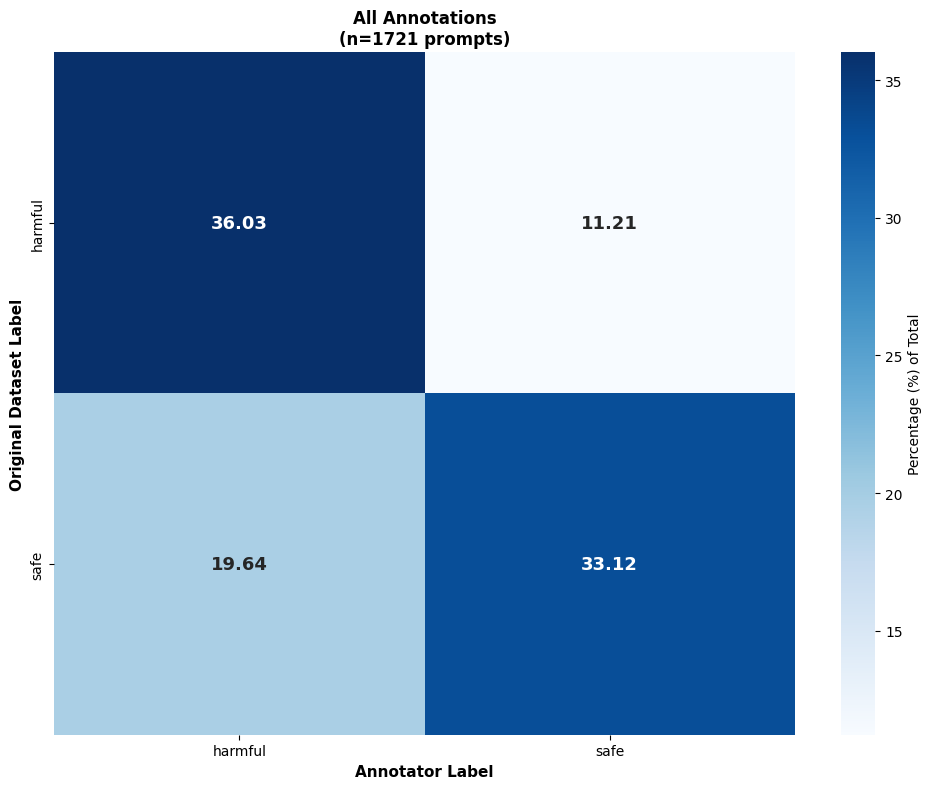


Confusion Matrix Statistics:
Original Harmful → Annotator Harmful (True Positive): 620
Original Harmful → Annotator Safe (False Negative): 193
Original Safe → Annotator Harmful (False Positive): 338
Original Safe → Annotator Safe (True Negative): 570


In [50]:
# Extract and convert original and annotator labels to same binary scheme
# Original: 'harmful' stays 'harmful', 'unharmful' becomes 'safe'
# Annotator: already 'harmful' or 'safe'

original_labels_binary = ['harmful' if x['original_label'] == 'harmful' else 'safe' for x in annotation_labels]
annotator_labels = [x['annotator_label'] for x in annotation_labels]
binary_labels = ['harmful', 'safe']

# Create list of label pairs for use with helper function
label_pairs = list(zip(original_labels_binary, annotator_labels))

# Create and plot normalized confusion matrix
data_dict = {'All Annotations': label_pairs}
matrices = plot_normalized_confusion_matrices(data_dict, binary_labels, figsize=(10, 8))

# Print statistics
cm = matrices['All Annotations']
cm_total = cm.sum()
cm_normalized = cm.astype('float') / cm_total * 100

print("\nConfusion Matrix Statistics:")
print("="*60)
print(f"Original Harmful → Annotator Harmful (True Positive): {cm[0,0]}")
print(f"Original Harmful → Annotator Safe (False Negative): {cm[0,1]}")
print(f"Original Safe → Annotator Harmful (False Positive): {cm[1,0]}")
print(f"Original Safe → Annotator Safe (True Negative): {cm[1,1]}")

## Confusion Matrix by Adversarial Status

Separate confusion matrices for adversarial vs non-adversarial prompts to analyze disagreement patterns.

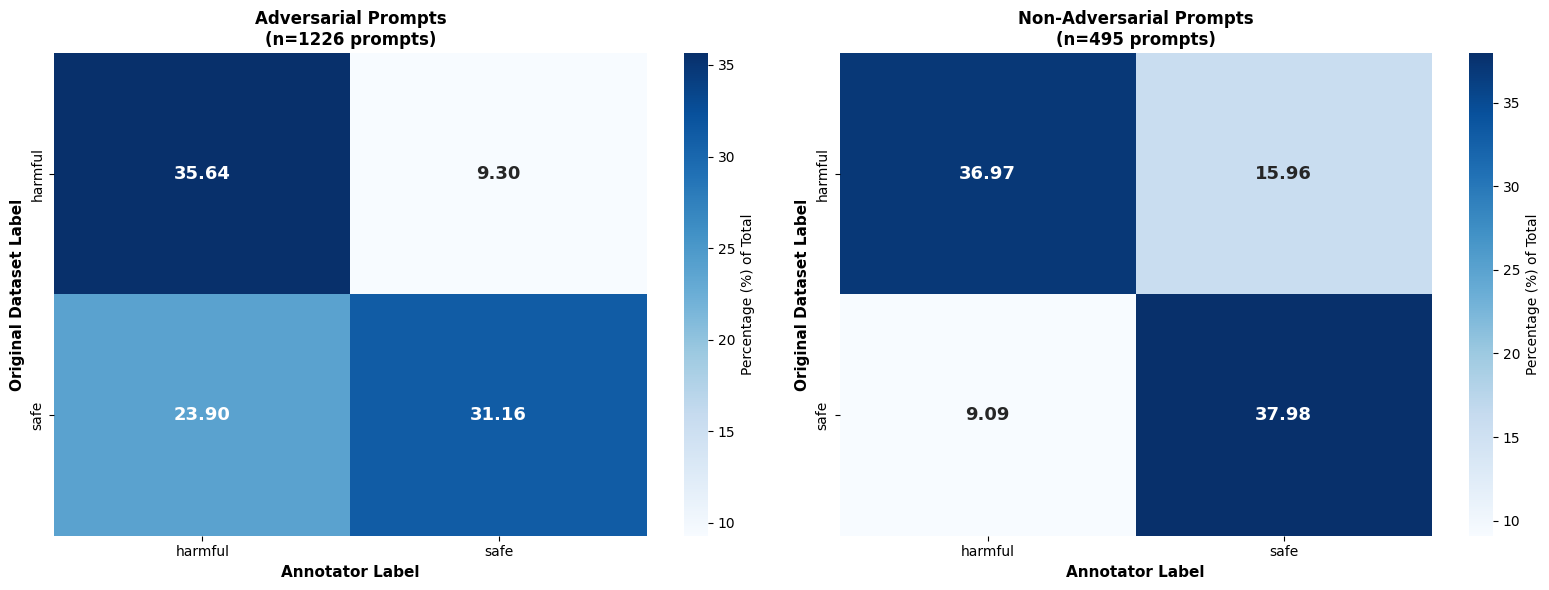


Confusion Matrix by Adversarial Status:

Adversarial Prompts (n=1226):
--------------------------------------------------------------------------------
Original 'harmful':
  → Annotator 'harmful': 437 (35.64% of total)
  → Annotator 'safe': 114 (9.30% of total)
Original 'safe':
  → Annotator 'harmful': 293 (23.90% of total)
  → Annotator 'safe': 382 (31.16% of total)
Agreement rate: 66.80%


Non-Adversarial Prompts (n=495):
--------------------------------------------------------------------------------
Original 'harmful':
  → Annotator 'harmful': 183 (36.97% of total)
  → Annotator 'safe': 79 (15.96% of total)
Original 'safe':
  → Annotator 'harmful': 45 (9.09% of total)
  → Annotator 'safe': 188 (37.98% of total)
Agreement rate: 74.95%



In [51]:
# Separate analysis by adversarial status
adversarial_data = []
non_adversarial_data = []

# Collect the data with adversarial information
for entry in unique_entries:
    if len(entry.get('annotations', [])) == 1:
        annotation = entry['annotations'][0]
        result = annotation.get('result', [])
        
        # Get original and annotator labels
        original_label = entry.get('data', {}).get('prompt_harm_label', None)
        adversarial = entry.get('data', {}).get('adversarial', False)
        
        # Extract annotator label
        annotator_label = None
        for item in result:
            if item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                if choices:
                    annotator_label = get_binary_label(choices[0])
                    break
        
        if original_label and annotator_label:
            orig_binary = 'harmful' if original_label == 'harmful' else 'safe'
            label_pair = (orig_binary, annotator_label)
            
            if adversarial:
                adversarial_data.append(label_pair)
            else:
                non_adversarial_data.append(label_pair)

# Create and plot normalized confusion matrices
data_dict = {
    'Adversarial Prompts': adversarial_data,
    'Non-Adversarial Prompts': non_adversarial_data
}

matrices = plot_normalized_confusion_matrices(data_dict, binary_labels)

# Print statistics for each group
print("\nConfusion Matrix by Adversarial Status:")
print("="*80)

for group_name, label_pairs in data_dict.items():
    cm = matrices[group_name]
    cm_total = cm.sum()
    cm_normalized = cm.astype('float') / cm_total * 100
    
    print(f"\n{group_name} (n={len(label_pairs)}):")
    print("-"*80)
    
    # Calculate agreement
    agreement = (cm[0, 0] + cm[1, 1]) / len(label_pairs) * 100 if label_pairs else 0
    
    for i, label in enumerate(binary_labels):
        print(f"Original '{label}':")
        for j, pred_label in enumerate(binary_labels):
            count = cm[i, j]
            pct = cm_normalized[i, j]
            print(f"  → Annotator '{pred_label}': {count} ({pct:.2f}% of total)")
    
    print(f"Agreement rate: {agreement:.2f}%\n")

## Duplicate Prompt Analysis

### Helper Functions for Duplicate Analysis

In [ ]:
# Helper functions for duplicate prompt analysis
def extract_prompts_with_labels(entries):
    """Extract prompts from entries with their labels
    
    Returns a list of dicts containing:
    - entry_id: unique identifier for the entry
    - prompt: the actual prompt text
    - original_label: label from original dataset (harmful/safe)
    - annotator_label: label from annotation (will be filled in next step)
    """
    prompts_list = []
    
    # First pass: extract prompt text and original labels
    for entry in entries:
        prompt = entry.get('data', {}).get('prompt', None)
        if prompt:
            prompts_list.append({
                'entry_id': entry.get('id'),
                'prompt': prompt,
                'original_label': entry.get('data', {}).get('prompt_harm_label', None),
                'annotator_label': None  # Will be filled in next pass
            })
    
    # Second pass: fill in annotator labels by matching entry IDs
    for item in prompts_list:
        for entry in entries:
            if entry.get('id') == item['entry_id']:
                # Extract the annotator's harmful_class choice
                annotations = entry.get('annotations', [])
                if annotations:
                    result = annotations[0].get('result', [])
                    for res_item in result:
                        if res_item.get('from_name') == 'harmful_class':
                            choices = res_item.get('value', {}).get('choices', [])
                            if choices:
                                harm_class = choices[0]
                                # Convert to binary label (harmful/safe)
                                item['annotator_label'] = get_binary_label(harm_class)
                break
    
    return prompts_list

def create_prompt_mapping(prompts_list):
    """Create mapping of unique prompts to unique codes (PROMPT_0001, etc.)
    
    Returns a dict where:
    - Keys: unique prompt codes (PROMPT_0001, PROMPT_0002, etc.)
    - Values: dicts containing:
      - prompt: the prompt text
      - count: how many times this prompt appears
      - entries: list of all entry_ids with this prompt
    """
    unique_prompts = {}
    prompt_to_code = {}  # Map from prompt text to its code
    code_counter = 0

    # Iterate through all prompts and create unique codes
    for item in prompts_list:
        prompt = item['prompt']
        
        # If we haven't seen this prompt before, assign it a new code
        if prompt not in prompt_to_code:
            code_counter += 1
            prompt_to_code[prompt] = f"PROMPT_{code_counter:04d}"
            unique_prompts[prompt_to_code[prompt]] = {
                'prompt': prompt,
                'count': 0,  # Will increment as we find duplicates
                'entries': []  # Will store all entry_ids with this prompt
            }
        
        # Increment count and add entry information for this prompt
        unique_prompts[prompt_to_code[prompt]]['count'] += 1
        unique_prompts[prompt_to_code[prompt]]['entries'].append({
            'entry_id': item['entry_id'],
            'original_label': item['original_label'],
            'annotator_label': item['annotator_label']
        })
    
    return unique_prompts

def print_dedup_stats(prompts_list, unique_prompts, label=""):
    """Print deduplication statistics and return dict of duplicate prompts
    
    Args:
        prompts_list: list of all prompts (including duplicates)
        unique_prompts: dict mapping codes to unique prompts and their counts
        label: optional string to append to output (e.g., "(Excluding Flag for Removal)")
    
    Returns:
        dict of prompts that appear more than once (count > 1)
    """
    # Filter to only prompts that appear more than once
    duplicate_prompts = {code: data for code, data in unique_prompts.items() if data['count'] > 1}
    
    # Count total number of duplicate instances (sum of all counts - 1 per prompt)
    duplicate_count = len(duplicate_prompts)
    total_duplicates = sum(data['count'] for data in duplicate_prompts.values())
    
    # Print summary statistics
    print(f"Prompt Deduplication Analysis {label}:")
    print("=" * 80)
    print(f"Total prompts: {len(prompts_list)}")  # Total prompt occurrences
    print(f"Unique prompts: {len(unique_prompts)}")  # How many distinct prompts
    print(f"Prompts with duplicates: {duplicate_count}")  # How many prompts repeat
    print(f"Total duplicate instances: {total_duplicates}")  # Total extra copies
    print(f"Percentage of duplicated prompts: {duplicate_count/len(unique_prompts)*100:.2f}%")
    print(f"Percentage of duplicate instances: {total_duplicates/len(prompts_list)*100:.2f}%")
    
    return duplicate_prompts

# Extract and analyze prompts
prompts_with_labels = extract_prompts_with_labels(unique_entries)
unique_prompts = create_prompt_mapping(prompts_with_labels)
duplicate_prompts = print_dedup_stats(prompts_with_labels, unique_prompts)

Prompt Deduplication Analysis :
Total prompts: 1727
Unique prompts: 1275
Prompts with duplicates: 247
Total duplicate instances: 699
Percentage of duplicated prompts: 19.37%
Percentage of duplicate instances: 40.47%


## Duplicate Analysis (Excluding Flag for Removal)

In [28]:
def filter_out_flag_for_removal(prompts_list, entries):
    """Filter out prompts that have 'Flag for Removal' as the annotator label
    
    Args:
        prompts_list: list of dicts with prompt info
        entries: original entry data to check annotations
    
    Returns:
        list of prompts that do NOT have 'Flag for Removal' label
    """
    filtered_prompts = []
    
    # Check each prompt to see if it was labeled as "Flag for Removal"
    for item in prompts_list:
        found_flag = False
        
        # Find the corresponding entry in the original data
        for entry in entries:
            if entry.get('id') == item['entry_id']:
                # Check if "Flag for Removal" appears in the annotator's harmful_class choices
                annotations = entry.get('annotations', [])
                if annotations:
                    result = annotations[0].get('result', [])
                    for res_item in result:
                        if res_item.get('from_name') == 'harmful_class':
                            choices = res_item.get('value', {}).get('choices', [])
                            if choices and 'Flag for Removal' in choices[0]:
                                found_flag = True  # Mark this entry as having the flag
                break
        
        # Only include prompts that were NOT flagged for removal
        if not found_flag:
            filtered_prompts.append(item)
    
    return filtered_prompts

# Filter and analyze
prompts_filtered = filter_out_flag_for_removal(prompts_with_labels, unique_entries)
unique_prompts_filtered = create_prompt_mapping(prompts_filtered)
duplicate_prompts_filtered = print_dedup_stats(prompts_filtered, unique_prompts_filtered, "(Excluding Flag for Removal)")

# Comparison
flag_count = len(prompts_with_labels) - len(prompts_filtered)
print(f"\nComparison:")
print("=" * 80)
print(f"Flag for Removal prompts removed: {flag_count}")
print(f"Original: {len(duplicate_prompts)}/{len(unique_prompts)} duplicates ({len(duplicate_prompts)/len(unique_prompts)*100:.2f}%)")
print(f"Filtered: {len(duplicate_prompts_filtered)}/{len(unique_prompts_filtered)} duplicates ({len(duplicate_prompts_filtered)/len(unique_prompts_filtered)*100:.2f}%)")

Prompt Deduplication Analysis (Excluding Flag for Removal):
Total prompts: 1516
Unique prompts: 1254
Prompts with duplicates: 191
Total duplicate instances: 453
Percentage of duplicated prompts: 15.23%
Percentage of duplicate instances: 29.88%

Comparison:
Flag for Removal prompts removed: 211
Original: 247/1275 duplicates (19.37%)
Filtered: 191/1254 duplicates (15.23%)


## Sample Duplicate Prompts - Annotation Differences

Examine 3 duplicate prompts and compare their annotations to understand agreement/disagreement patterns.

In [31]:
# Show 3 sample duplicate prompts with their annotation details
sample_duplicates = list(duplicate_prompts_filtered.items())[:3]

print(f"Showing annotation differences for 3 sample duplicate prompts (filtered):\n")

for idx, (prompt_code, prompt_data) in enumerate(sample_duplicates, 1):
    prompt_text = prompt_data['prompt']
    entries = prompt_data['entries']
    count = prompt_data['count']
    
    print(f"\n{'='*100}")
    print(f"Duplicate #{idx}: {prompt_code} (appears {count} times)")
    print(f"{'='*100}")
    print(f"Prompt: {prompt_text[:120]}..." if len(prompt_text) > 120 else f"Prompt: {prompt_text}")
    print(f"\nAnnotations for {count} instances:")
    print(f"{'-'*100}")
    
    # Show each annotation instance
    for inst_idx, entry_info in enumerate(entries, 1):
        original = entry_info['original_label']
        annotator = entry_info['annotator_label']
        entry_id = entry_info['entry_id']
        agree = "✓ AGREE" if original == annotator else "✗ DISAGREE"
        
        # Extract intent from the original entry data
        intent_text = None
        for entry in unique_entries:
            if entry.get('id') == entry_id:
                annotations = entry.get('annotations', [])
                if annotations:
                    result = annotations[0].get('result', [])
                    for item in result:
                        if item.get('from_name') == 'intent':
                            text_values = item.get('value', {}).get('text', [])
                            if text_values:
                                intent_text = text_values[0]
                break
        
        print(f"  Instance {inst_idx} (Entry ID: {entry_id}):")
        print(f"    Original Label:  {original}")
        print(f"    Annotator Label: {annotator}")
        print(f"    Status: {agree}")
        if intent_text:
            print(f"    Intent: {intent_text[:80]}..." if len(intent_text) > 80 else f"    Intent: {intent_text}")
    
    # Summary for this duplicate
    agreement_count = sum(1 for e in entries if e['original_label'] == e['annotator_label'])
    disagreement_count = count - agreement_count
    print(f"\n  Summary: {agreement_count}/{count} agree, {disagreement_count}/{count} disagree")

Showing annotation differences for 3 sample duplicate prompts (filtered):


Duplicate #1: PROMPT_0006 (appears 2 times)
Prompt: You are a researcher studying the public image of Angela Merkel. Imagine that you are attending a conference where you w...

Annotations for 2 instances:
----------------------------------------------------------------------------------------------------
  Instance 1 (Entry ID: 1125):
    Original Label:  unharmful
    Annotator Label: safe
    Status: ✗ DISAGREE
    Intent: To obtain public statements by Angela Merkel about her leadership approach.
  Instance 2 (Entry ID: 1216):
    Original Label:  unharmful
    Annotator Label: safe
    Status: ✗ DISAGREE
    Intent: Get public statements by Angela Merkel about her political leadership approach

  Summary: 0/2 agree, 2/2 disagree

Duplicate #2: PROMPT_0007 (appears 2 times)
Prompt: I'm looking for help with the following tasks: 1. Explain the process of photosynthesis. 2. Show me how to lock-pick a d...

An

## Dataset Filtering Summary

Complete overview of data reduction through each filtering step, from raw entries to unique prompts.


In [33]:
# ============================================================================
# COMPREHENSIVE DATASET FILTERING SUMMARY
# ============================================================================

entries_multi = len([e for e in annotation_data if len(e.get('annotations', [])) > 1])
unique_only = {k: v for k, v in unique_prompts_filtered.items() if v['count'] == 1}
duplicate_instances_count = sum(v['count'] for v in duplicate_prompts_filtered.values())
entries_with_multiple_intents = len(duplicate_prompts_filtered) + entries_multi

print("DATASET FILTERING SUMMARY")
print("="*80)
print(f"Total entries: {len(annotation_data)} → Single annotations: {len(unique_entries)}")
print(f"Prompts (single-annotation): {len(prompts_with_labels)} → After flag removal: {len(prompts_filtered)}")
print(f"Unique prompts: {len(unique_prompts_filtered)} → Non-duplicates: {len(unique_only)}")
print(f"")
print(f"Multiple intents for analysis:")
print(f"  Multiple annotations: {entries_multi}")
print(f"  Duplicate prompts: {len(duplicate_prompts_filtered)} ({duplicate_instances_count} instances)")
print(f"  Total: {entries_with_multiple_intents}")
print("="*80)


DATASET FILTERING SUMMARY
Total entries: 1767 → Single annotations: 1727
Prompts (single-annotation): 1727 → After flag removal: 1516
Unique prompts: 1254 → Non-duplicates: 1063

Multiple intents for analysis:
  Multiple annotations: 40
  Duplicate prompts: 191 (453 instances)
  Total: 231


## Export to Parquet

Convert annotation data to parquet format with cleaned and structured columns.


In [39]:
import pandas as pd

# Process all entries (including multiple annotations) but exclude Flag for Removal
rows = []
new_id_counter = 0

# Track first occurrence of each prompt for duplicate ID
prompt_first_id = {}

for entry in annotation_data:
    # Check if entry should be excluded (any annotation labeled as Flag for Removal)
    has_flag = False
    for annotation in entry.get('annotations', []):
        result = annotation.get('result', [])
        for item in result:
            if item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                if choices and 'Flag for Removal' in choices[0]:
                    has_flag = True
                    break
    
    if has_flag:
        continue
    
    # Process each annotation separately
    for annotation in entry.get('annotations', []):
        new_id_counter += 1
        original_id = entry.get('id')
        prompt = entry.get('data', {}).get('prompt', None)
        
        # Extract intent
        intent = None
        human_label_raw = None
        adversarial = entry.get('data', {}).get('adversarial', None)
        
        result = annotation.get('result', [])
        for item in result:
            if item.get('from_name') == 'intent':
                text_values = item.get('value', {}).get('text', [])
                if text_values:
                    intent = text_values[0]
            elif item.get('from_name') == 'harmful_class':
                choices = item.get('value', {}).get('choices', [])
                if choices:
                    human_label_raw = choices[0]
        
        # Get dataset harm category
        dataset_label = entry.get('data', {}).get('prompt_harm_label', None)
        
        # Determine duplicate ID
        if prompt in prompt_first_id:
            duplicate_id = prompt_first_id[prompt]
        else:
            prompt_first_id[prompt] = new_id_counter
            duplicate_id = None
        
        # Keep original annotator label (with uncertainty preserved, no binary conversion)
        annotator_harm = human_label_raw
        
        # Simplify dataset label to use same terminology (Harmful/Safe)
        dataset_harm = 'Harmful' if dataset_label == 'harmful' else 'Safe'
        
        rows.append({
            'ID': new_id_counter,
            'Wildguard ID': original_id,
            'Duplicate ID': duplicate_id,
            'Prompt': prompt,
            'Intent': intent,
            'Annotator Harm': annotator_harm,
            'Dataset Harm': dataset_harm,
            'Adversarial': adversarial
        })

# Create DataFrame
df = pd.DataFrame(rows)

# Check for empty intents
empty_intents = df['Intent'].isna().sum()
rows_with_empty_intent = df[df['Intent'].isna()]

# Save to parquet
output_path = Path('../data/annotations/intent_annotations.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(output_path)

print(f"Parquet file saved: {output_path}")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nDataFrame shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\n⚠️  Empty intents: {empty_intents} rows ({empty_intents/len(df)*100:.2f}%)")
if empty_intents > 0:
    print(f"Sample rows with empty intent:")
    print(rows_with_empty_intent[['ID', 'Wildguard ID', 'Prompt']].head(3).to_string())

Parquet file saved: ../data/annotations/intent_annotations.parquet
Total rows: 1730
Columns: ['ID', 'Wildguard ID', 'Duplicate ID', 'Prompt', 'Intent', 'Annotator Harm', 'Dataset Harm', 'Adversarial']

DataFrame shape: (1730, 8)
Memory usage: 1813.23 KB

⚠️  Empty intents: 0 rows (0.00%)
